### Task 1. 

#### Setup

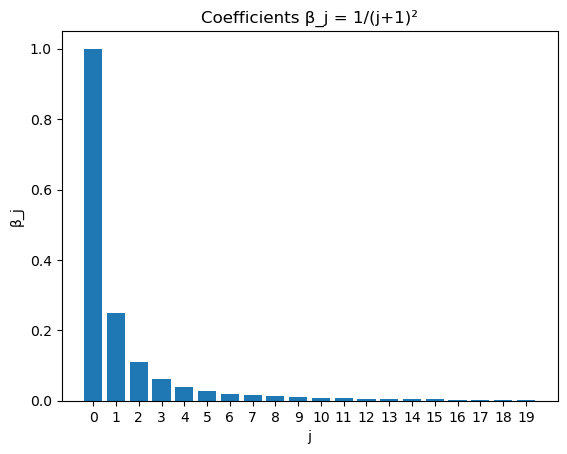

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prng = np.random.RandomState(20260304)

def generateBeta(n_features):
    return [1/(j + 1)**2 for j in range(n_features)]

def generateData(n_samples, n_features, prng):
    X = pd.DataFrame(prng.multivariate_normal(
        mean=np.repeat(0, n_features), 
        cov=np.eye(n_features), 
        size=n_samples
    ))
    beta = generateBeta(n_features)
    y = np.dot(X, beta) + prng.normal(0, 1, size=n_samples)
    return X, y

p = 20
plt.bar(range(p), generateBeta(p))
plt.xlabel('j')
plt.xticks(range(p))
plt.ylabel('β_j')
plt.title('Coefficients β_j = 1/(j+1)²')
plt.show()


#### Data generation

In [2]:
X, y = generateData(100, p, prng)

In [3]:
df = X.copy()
df['target'] = y

In [4]:
df.shape

(100, 21)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
0,1.473128,0.173873,0.597739,-0.203250,-0.539590,0.070841,0.030568,0.141742,0.976868,-1.397084,...,0.582031,1.075671,0.412505,0.012493,-0.324095,-2.123575,-0.254821,-0.168330,0.297756,1.909077
1,0.341140,-0.673455,0.483230,1.216759,-1.235973,0.439807,-0.283628,-1.122933,-0.472587,0.473086,...,-1.193356,-0.631111,-0.073421,-0.451639,1.316069,-1.850506,0.128097,1.886451,0.826198,0.578090
2,-2.262032,-0.808033,0.056108,0.612049,-0.439954,-0.750352,0.140418,1.639841,0.242362,-0.215751,...,-0.178890,-0.061728,-2.057322,-0.756615,0.309282,0.032082,-0.709926,-0.202002,-1.551182,-2.679176
3,-1.741048,-0.013556,0.923778,-0.689904,-1.223334,2.249642,0.972914,0.755310,0.489125,0.747455,...,0.850864,1.417672,1.161743,0.647093,-0.140947,0.906571,-0.343083,-0.013671,-0.957102,-2.239705
4,0.151137,1.200260,-0.703816,-0.404897,-1.955054,-0.250304,0.380054,-0.860433,0.617659,1.508583,...,0.192230,-0.833830,1.171504,0.786191,2.812694,1.315476,0.568391,-0.289842,-0.271404,1.408060


In [6]:
df[1].count()

np.int64(100)

#### Lasso implementation

Train / test division

In [7]:
from sklearn.model_selection import train_test_split

X_full = df.drop('target', axis=1) 

y_full = df['target'] 

X_train, X_test, y_train, y_test = train_test_split(
    X_full, 
    y_full, 
    test_size=0.2, 
    random_state=24 
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (80, 20)
Shape of y_train: (80,)
Shape of X_test: (20, 20)
Shape of y_test: (20,)


In [8]:
from sklearn.linear_model import LassoCV

k_folds = 5 

lasso_cv = LassoCV(cv=k_folds, random_state=24)

lasso_cv.fit(X_train, y_train)

optimal_alpha = lasso_cv.alpha_

print(f"Optimal alpha selected by CV: {optimal_alpha:.4f}")
print(f"Number of iterations to converge: {lasso_cv.n_iter_}")

Optimal alpha selected by CV: 0.0747
Number of iterations to converge: 7


#### Justification

5-fold cross-validation is chosen because it provides a decent balance of statistical validity and computational efficiency for the given size of training set. Statistically, it leaves 64 samples for training in each fold, ensuring the model has enough data to learn the 20 features without becoming highly unstable. Simultaneously, it leaves 16 samples for validation, which provides a much more reliable performance estimate than tiny validation sets it would be got with 10-fold CV, for example. Computationally, performing 500 total fits (sklearn package sets a grid of 100 alphas by default) on a dataset of this size is almost instantly. 

### MSE display

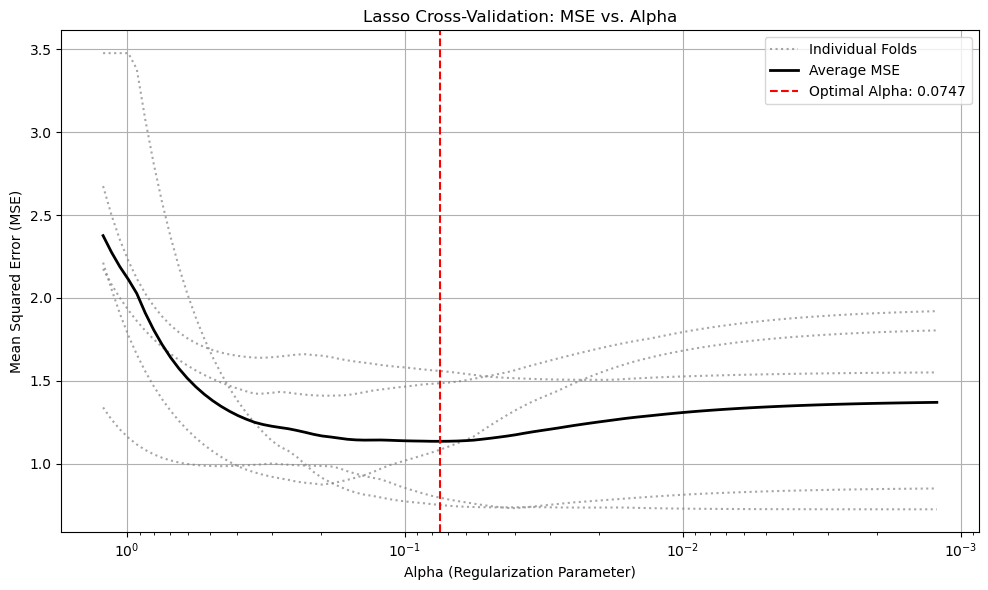

In [9]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path

plt.figure(figsize=(10, 6))

# Plot the MSE for each individual fold (grey dotted lines)
# lasso_cv.mse_path_ contains the MSE for each fold at each alpha
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_, ':', color='grey', alpha=0.7)

plt.plot([], [], ':', color='grey', alpha=0.7, label='Individual Folds')
    
mean_mse = lasso_cv.mse_path_.mean(axis=-1)
plt.plot(lasso_cv.alphas_, mean_mse, 'k-', linewidth=2, label='Average MSE')

plt.axvline(lasso_cv.alpha_, linestyle='--', color='r', 
            label=f'Optimal Alpha: {lasso_cv.alpha_:.4f}')

plt.semilogx()      
ax = plt.gca()
ax.invert_xaxis()  

plt.xlabel('Alpha (Regularization Parameter)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Cross-Validation: MSE vs. Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()

#### Chart interpretation

At high values of alpha, the model is penalized too heavily and discards most of the useful features, leading to significant underfitting and high error. The optimal value of alpha (red dotted line) is achieved at the point of minimum MSE, where the algorithm finds the ideal balance, leaving only the most significant predictors. With a further decrease in alpha, the penalty becomes too weak, the algorithm stops filtering out noise, and the validation error may start to increase again due to overfitting.

#### Beta display by alphas

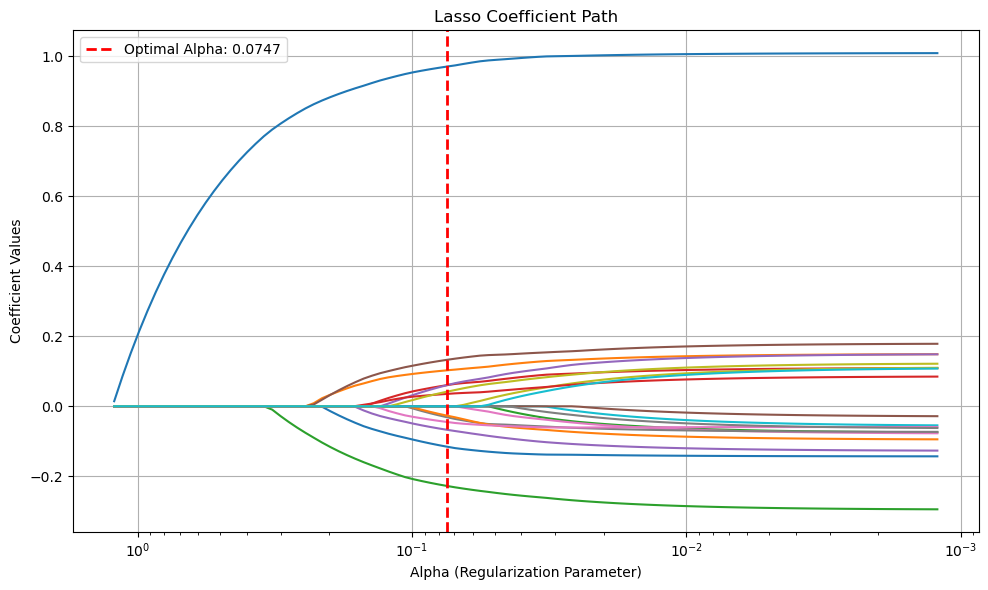

In [10]:
alphas = lasso_cv.alphas_

alphas_lasso, coefs_lasso, _ = lasso_path(X_train, y_train, alphas=alphas)

plt.figure(figsize=(10, 6))

for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])

plt.axvline(lasso_cv.alpha_, linestyle='--', color='r', linewidth=2, 
            label=f'Optimal Alpha: {lasso_cv.alpha_:.4f}')

plt.semilogx() 
ax = plt.gca()
ax.invert_xaxis() 

plt.xlabel('Alpha (Regularization Parameter)')
plt.ylabel('Coefficient Values')
plt.title('Lasso Coefficient Path')
plt.legend()
plt.grid(True)
plt.tight_layout()

#### Chart interpretation

The coefficient graph clearly demonstrates how a strong penalty (left side) forces all feature coefficients to be completely shrinked out, creating a sparse model. As alpha decreases, the penalty weakens, and the most significant features (those with the largest true values of beta) are the first to “enter” the model and increase in magnitude. The vertical line marks the optimal value of alpha, indicating the exact point at which the model balances the compression of noise features to zero while preserving the most informative non-zero coefficients.

### Task 2

#### Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import radians, cos, sin, asin, sqrt

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

prng = np.random.RandomState(20260317)

pd.set_option('display.precision', 3)
plt.rcParams['figure.dpi'] = 110

In [12]:
# Load the pre-generated sample files
folder_path = '../../data/nyc_taxi/' # Adjust this path if your data is located elsewhere
taxi_500 = pd.read_csv(f'{folder_path}taxi_500.csv', parse_dates=['pickup_datetime'])
taxi_5k = pd.read_csv(f'{folder_path}taxi_5k.csv', parse_dates=['pickup_datetime'])
taxi_50k = pd.read_csv(f'{folder_path}taxi_50k.csv', parse_dates=['pickup_datetime'])
taxi_test = pd.read_csv(f'{folder_path}taxi_test.csv', parse_dates=['pickup_datetime'])

print(f'Small sample: {len(taxi_500):,} trips')
print(f'Medium sample: {len(taxi_5k):,} trips')
print(f'Large sample: {len(taxi_50k):,} trips')
print(f'Test set: {len(taxi_test):,} trips')
print()
print('Columns:', list(taxi_500.columns))
print()

# Preview the small sample
taxi_500.head()

Small sample: 480 trips
Medium sample: 4,992 trips
Large sample: 49,992 trips
Test set: 20,000 trips

Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'distance_km', 'pickup_hour']



,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour
0,id3185270,1,2016-06-18 00:07:04,2016-06-18 00:32:29,1,-73.782,40.644,-73.919,40.747,N,1525,16.239,0
1,id2576766,1,2016-06-03 00:23:46,2016-06-03 00:26:48,1,-73.989,40.759,-73.989,40.768,N,182,1.011,0
2,id3884599,2,2016-03-20 00:55:40,2016-03-20 01:16:02,5,-73.955,40.768,-73.999,40.729,N,1222,5.786,0
3,id2036663,2,2016-03-25 00:57:38,2016-03-25 01:03:17,1,-73.983,40.768,-73.989,40.775,N,339,0.886,0
4,id0355898,2,2016-05-26 00:47:45,2016-05-26 00:54:57,1,-73.946,40.782,-73.948,40.804,N,432,2.478,0


#### Data Exploration

In [13]:
taxi_500.describe()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,distance_km,pickup_hour
count,480.000,480,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000
mean,1.515,2016-03-28 09:03:22.181249792,1.723,-73.974,40.749,-73.970,40.751,891.765,3.584,11.500
min,1.000,2016-01-02 02:35:29,1.000,-74.016,40.644,-74.183,40.616,4.000,0.000,0.000
25%,1.000,2016-02-15 11:34:45.249999872,1.000,-73.991,40.735,-73.989,40.737,390.750,1.314,5.750
50%,2.000,2016-03-25 12:40:02,1.000,-73.982,40.753,-73.978,40.755,654.000,2.207,11.500
75%,2.000,2016-05-12 17:40:28.750000128,2.000,-73.970,40.765,-73.960,40.769,1040.250,4.094,17.250
max,2.000,2016-06-30 21:55:32,6.000,-73.777,40.818,-73.776,40.855,43749.000,23.734,23.000
std,0.500,NaN,1.381,0.037,0.027,0.040,0.033,2056.229,4.035,6.929


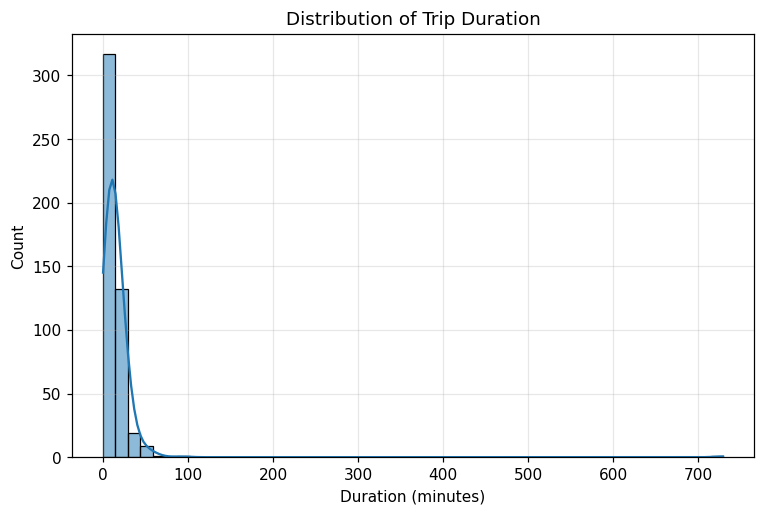

In [14]:
# Plot 1: Distribution of Trip Duration

taxi_500['duration_min'] = taxi_500['trip_duration'] / 60

plt.figure(figsize=(8, 5))
sns.histplot(taxi_500['duration_min'], bins=50, kde=True)

plt.title('Distribution of Trip Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

plt.show()

#### Commentaty to the first chart: 

there are clear extreme outliers, which is evident from the long right tail extending beyond 700 minutes for a single trip. Because the distribution is severely right-skewed, applying a log transformation is highly recommended. This will help normalize the distribution and prevent these massive outlier values from distorting predictions.

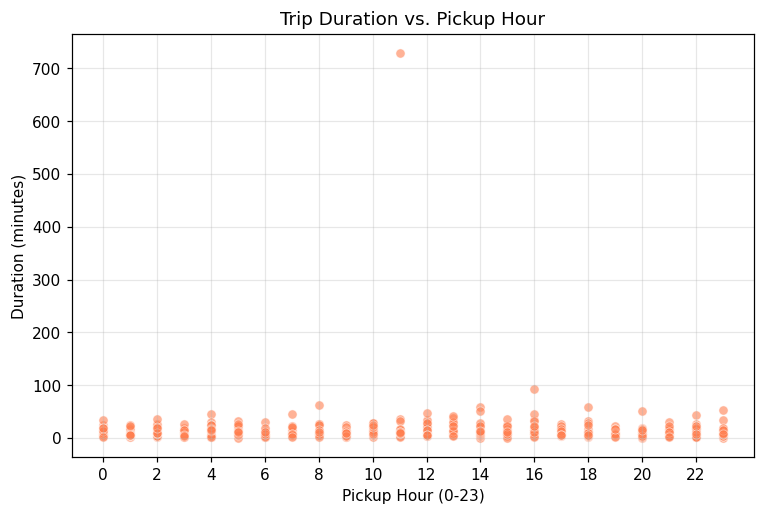

In [15]:
# Plot 2: Trip Duration vs. Pickup Hour
plt.figure(figsize=(8, 5))
sns.scatterplot(data=taxi_500, x='pickup_hour', y='duration_min', alpha=0.6, color='coral')

plt.title('Trip Duration vs. Pickup Hour')
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Duration (minutes)')

plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)

plt.show()

#### Commentary to the second chart:

Due to the extreme 700-minute outlier compressing the y-axis, it is currently very difficult to observe any temporal patterns in the scatter plot. While the vast majority of trips consistently take under 100 minutes regardless of the hour, typical daily trends like rush hour peaks or night time are completely obscured. Maybe it would be better to remove this outlier or apply the log transformation which was discussed earlier to properly reveal how trip duration changes throughout the day.

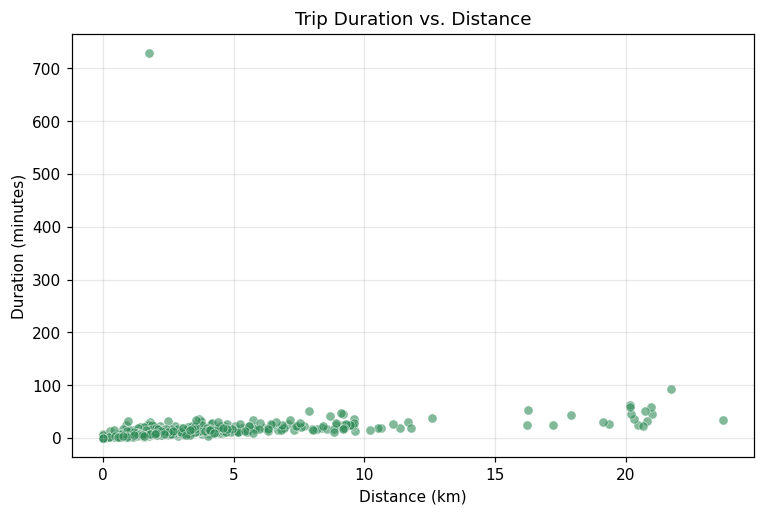

In [16]:
# Plot 3: Trip Duration vs. Distance

plt.figure(figsize=(8, 5))
sns.scatterplot(data=taxi_500, x='distance_km', y='duration_min', alpha=0.6, color='seagreen')

plt.title('Trip Duration vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Duration (minutes)')
plt.grid(True, alpha=0.3)

plt.show()

In [17]:
correlation = taxi_500['duration_min'].corr(taxi_500['distance_km'])
print(f"Correlation coefficient between distance and duration: {correlation:.3f}")

Correlation coefficient between distance and duration: 0.210


#### Commentary to the third chart:

For the vast majority of the data points clustered at the bottom, distance appears to be a solid predictor of duration, showing a clear positive trend where longer distances take more time. However, the calculated correlation coefficient is quite low (0.210) because it is being severely distorted by outliers (which has a very short distance but a huge duration)

#### The choice of evaluation metric:

When predicting taxi arrival times, we are much more concerned with relative error than absolute error. A 5-minute deviation on a 10-minute trip causes enormous inconvenience to the passenger (50% error). However, a 5-minute deviation on a 60-minute trip to the airport is barely noticeable (8% error). RMSLE perfectly reflects this by penalizing the ratio of predicted and actual values, rather than the raw difference in minutes. Furthermore, as seen in the example of the 700-minute outlier, using standard RMSE would result in a significant overestimation of the model index due to rare, extreme anomalies, whereas RMSLE naturally mitigates their impact.

**The choice**: RMSLE

In [18]:
# Define RMSLE metric
def calculateRMSLE(prediction, y_obs):
    return np.sqrt(
        np.mean(
            (np.log(np.maximum(prediction, 0) + 1) - np.log(y_obs + 1))**2
        )
    )

In [19]:
# Helper class to track all models
class ResultCollector:
    def __init__(self):
        self.results = {}
        
    def add_model(self, name, train_error, test_error):
        """Add or update a model's results."""
        self.results[name] = {
            'Train RMSLE': train_error,
            'Test RMSLE': test_error,
            'Gap': test_error - train_error
        }
        return self.get_table()
    
    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        df['Improvement over Benchmark'] = df['Test RMSLE'].apply(
            lambda x: f"{round(100 * (df['Test RMSLE'].iloc[0] - x) / df['Test RMSLE'].iloc[0], 1)}%"
        )
        if style:
            return df.style.format("{:.3f}", subset=['Train RMSLE', 'Test RMSLE', 'Gap']).background_gradient(cmap='RdYlGn_r', subset=['Test RMSLE'], axis=None)
        return df

# Initialize results tracker
results = ResultCollector()

#### Setting a benchmark as a mean value

In [20]:
taxi_500.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,duration_min
0,id3185270,1,2016-06-18 00:07:04,2016-06-18 00:32:29,1,-73.782,40.644,-73.919,40.747,N,1525,16.239,0,25.417
1,id2576766,1,2016-06-03 00:23:46,2016-06-03 00:26:48,1,-73.989,40.759,-73.989,40.768,N,182,1.011,0,3.033
2,id3884599,2,2016-03-20 00:55:40,2016-03-20 01:16:02,5,-73.955,40.768,-73.999,40.729,N,1222,5.786,0,20.367
3,id2036663,2,2016-03-25 00:57:38,2016-03-25 01:03:17,1,-73.983,40.768,-73.989,40.775,N,339,0.886,0,5.650
4,id0355898,2,2016-05-26 00:47:45,2016-05-26 00:54:57,1,-73.946,40.782,-73.948,40.804,N,432,2.478,0,7.200


In [21]:
features = ['distance_km'] 

X_train = taxi_500[features]
y_train = taxi_500['trip_duration'] 

X_test = taxi_test[features]
y_test = taxi_test['trip_duration'] 

print(f"The shape of (X_train): {X_train.shape}")
print(f"The shape of (X_test): {X_test.shape}")

The shape of (X_train): (480, 1)
The shape of (X_test): (20000, 1)


In [22]:
# Baseline: predict mean
baseline_pred = np.mean(y_train)

train_error = calculateRMSLE(np.full(len(y_train), baseline_pred), y_train)
test_error = calculateRMSLE(np.full(len(y_test), baseline_pred), y_test)

print(f"Baseline (mean): {baseline_pred:.1f} seconds")

results.add_model("Mean", train_error, test_error)

Baseline (mean): 891.8 seconds


,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%


#### Building models

Linear regression using only `distance_km`

In [23]:
numeric_features = ['distance_km']

pipe_linear_distance = Pipeline([
    ('features', ColumnTransformer([
        ('num', 'passthrough', numeric_features)
    ])),
    ('model', LinearRegression())
])

pipe_linear_distance.fit(X_train, y_train)

train_error = calculateRMSLE(pipe_linear_distance.predict(X_train), y_train)
test_error = calculateRMSLE(pipe_linear_distance.predict(X_test), y_test)

results.add_model("Linear (distance_km)", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%


Multivariate linear regression with distance + temporal features

In [24]:
def extract_datetime_features(df):
    """Extract temporal features from datetime column."""
    df = df.copy()
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['month'] = df['pickup_datetime'].dt.month
    df['hour'] = df['pickup_datetime'].dt.hour
    df['dayofweek'] = df['pickup_datetime'].dt.dayofweek
    return df

# Apply feature engineering
taxi_500 = extract_datetime_features(taxi_500)
taxi_test = extract_datetime_features(taxi_test)

In [25]:
new_features = ['distance_km', 'month', 'hour', 'dayofweek']

X_train = taxi_500[new_features]
X_test = taxi_test[new_features]

print(f"Updated X_train: {X_train.shape}")
print(f"Updated X_test: {X_test.shape}")

Updated X_train: (480, 4)
Updated X_test: (20000, 4)


In [26]:
numeric_features = ['distance_km', 'month', 'hour', 'dayofweek']

pipe_linear_weather = Pipeline([
    ('features', ColumnTransformer([
        ('num', 'passthrough', numeric_features)
    ])),
    ('model', LinearRegression())
])

pipe_linear_weather.fit(X_train, y_train)

train_error = calculateRMSLE(pipe_linear_weather.predict(X_train), y_train)
test_error = calculateRMSLE(pipe_linear_weather.predict(X_test), y_test)

results.add_model("Multivariate LR", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%


#### Decision Tree

In [27]:
tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=prng)
tree_shallow.fit(X_train, y_train)

train_error = calculateRMSLE(tree_shallow.predict(X_train), y_train)
test_error = calculateRMSLE(tree_shallow.predict(X_test), y_test)

results.add_model("Tree (depth=3)", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%


#### Commentary to results:

* Linear Regression (distance_km): This model significantly outperformed the baseline, improving the Test RMSLE by 25.1%. This confirms that distance is the critical predictor for trip duration.

* Multivariate Linear Regression: Adding temporal features did not help this specific model, as the Test RMSLE actually worsened to 0.667. This suggests that a simple linear model struggles to extract value from time-based features without non-linear transformations like one-hot encoding.

* Decision Tree (depth=3): The tree model is the best performer, achieving the lowest Test RMSLE of 0.615 and a 27.8% improvement over the baseline. It captures non-linear patterns much better than the linear models.

#### Random Forest

In [28]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=prng)

rf_model.fit(X_train, y_train)

train_error = calculateRMSLE(rf_model.predict(X_train), y_train)
test_error = calculateRMSLE(rf_model.predict(X_test), y_test)

results.add_model("Random Forest (depth=3)", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%


#### Commentary to RF:

Random Forest reduced the error gap compared to the single Decision Tree, showing a negative gap of -0.014. By averaging multiple trees, it reduces model variance and overfitting, which is clearly seen when compared to the high-variance Tree that had a much larger gap of 0.023. This ensemble approach balances the bias-variance trade-off more effectively, providing better generalization on the test set.


#### Feature Engineering

In [29]:
def add_domain_features(df):
    df = df.copy()
    
    df['manhattan_dist'] = (abs(df['dropoff_latitude'] - df['pickup_latitude']) + 
                            abs(df['dropoff_longitude'] - df['pickup_longitude']))

    # Airport Proximity (JFK and LGA)
    jfk = (40.64, -73.78)
    lga = (40.77, -73.87)
    
    def near_airport(row):
        for lat, lon in [jfk, lga]:
            if (abs(row['pickup_latitude'] - lat) < 0.02 and abs(row['pickup_longitude'] - lon) < 0.02) or \
               (abs(row['dropoff_latitude'] - lat) < 0.02 and abs(row['dropoff_longitude'] - lon) < 0.02):
                return 1
        return 0
    
    df['is_airport'] = df.apply(near_airport, axis=1)

    # nteraction Term: Distance × Rush Hour
    # Traffic significantly changes the "cost" of distance during peak hours
    df['is_rush_hour'] = df['pickup_hour'].isin([8, 9, 16, 17, 18]).astype(int)
    df['dist_rush_interaction'] = df['distance_km'] * df['is_rush_hour']
    
    return df

taxi_500 = add_domain_features(taxi_500)
taxi_test = add_domain_features(taxi_test)

new_features = numeric_features + ['manhattan_dist', 'is_airport', 'dist_rush_interaction']
X_train = taxi_500[new_features]
X_test = taxi_test[new_features]

In [30]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=prng)

rf_model.fit(X_train, y_train)

train_error = calculateRMSLE(rf_model.predict(X_train), y_train)
test_error = calculateRMSLE(rf_model.predict(X_test), y_test)

results.add_model("Random Forest (depth=3) with new features", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%


In [31]:
from sklearn.compose import TransformedTargetRegressor

model_ext = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p, inverse_func=np.expm1
).fit(X_train, y_train)


train_err = calculateRMSLE(model_ext.predict(X_train), y_train)
test_err = calculateRMSLE(model_ext.predict(X_test), y_test)
results.add_model("Linear (Full Features + Log)", train_err, test_err)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%


#### Commentary:

Feature engineering significantly improved the performance of both models, but provided a larger relative boost to the Random Forest, increasing its improvement over the benchmark from 29.6% to 32.97%. The transformation of the target variables was also applied (by log) and the test RMLSE was also improved from 21.7% to 27.7%. The jump is connected with adding a new information to the model, which in both cases gives more stable and accurate results.

#### Estimation by all data

In [32]:
taxi_5k = extract_datetime_features(taxi_5k)
taxi_50k = extract_datetime_features(taxi_50k)
taxi_test = extract_datetime_features(taxi_test)


taxi_5k = add_domain_features(taxi_5k)
taxi_50k = add_domain_features(taxi_50k)
taxi_test = add_domain_features(taxi_test)


In [33]:
print(f"Shape of taxi_500: {taxi_500.shape}") #21 variable because above duration_min was created 
print(f"Shape of taxi_5k: {taxi_5k.shape}")
print(f"Shape of taxi_50k: {taxi_50k.shape}")

Shape of taxi_500: (480, 21)
Shape of taxi_5k: (4992, 20)
Shape of taxi_50k: (49992, 20)


In [34]:
features = ['distance_km', 'month', 'hour', 'dayofweek', 'manhattan_dist', 'is_airport', 'dist_rush_interaction']

X_train_500 = taxi_500[features]
y_train_500 = taxi_500['trip_duration'] 

X_train_5k = taxi_5k[features]
y_train_5k = taxi_5k['trip_duration'] 

X_train_50k = taxi_50k[features]
y_train_50k = taxi_50k['trip_duration'] 

X_test = taxi_test[features]
y_test = taxi_test['trip_duration'] 

print(f"The shape of (X_train_500): {X_train_500.shape}")
print(f"The shape of (X_train_5k): {X_train_5k.shape}")
print(f"The shape of (X_train_50k): {X_train_50k.shape}")
print(f"The shape of (X_test): {X_test.shape}")

The shape of (X_train_500): (480, 7)
The shape of (X_train_5k): (4992, 7)
The shape of (X_train_50k): (49992, 7)
The shape of (X_test): (20000, 7)


In [35]:
lr_model_5k = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p, 
    inverse_func=np.expm1
)
lr_model_5k.fit(X_train_5k, y_train_5k)
results.add_model(
    "LR (5k Sample and Full Features)", 
    calculateRMSLE(lr_model_5k.predict(X_train_5k), y_train_5k), 
    calculateRMSLE(lr_model_5k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%


In [36]:
lr_model_50k = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p, 
    inverse_func=np.expm1
)
lr_model_50k.fit(X_train_50k, y_train_50k)
results.add_model(
    "LR (50k Sample and Full Features)", 
    calculateRMSLE(lr_model_50k.predict(X_train_50k), y_train_50k), 
    calculateRMSLE(lr_model_50k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%
LR (50k Sample and Full Features),0.609,0.605,-0.004,29.0%


In [37]:
dt_model_5k = DecisionTreeRegressor(max_depth=3, random_state=prng)
dt_model_5k.fit(X_train_5k, y_train_5k)
results.add_model(
    "Decision Tree (5k Sample and Full Features)", 
    calculateRMSLE(dt_model_5k.predict(X_train_5k), y_train_5k), 
    calculateRMSLE(dt_model_5k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%
LR (50k Sample and Full Features),0.609,0.605,-0.004,29.0%
Decision Tree (5k Sample and Full Features),0.758,0.704,-0.054,17.4%


In [38]:
dt_model_50k = DecisionTreeRegressor(max_depth=3, random_state=prng)
dt_model_50k.fit(X_train_50k, y_train_50k)
results.add_model(
    "Decision Tree (50k Sample and Full Features)", 
    calculateRMSLE(dt_model_50k.predict(X_train_50k), y_train_50k), 
    calculateRMSLE(dt_model_50k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%
LR (50k Sample and Full Features),0.609,0.605,-0.004,29.0%
Decision Tree (5k Sample and Full Features),0.758,0.704,-0.054,17.4%


In [39]:
rf_model_5k = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=prng)
rf_model_5k.fit(X_train_5k, y_train_5k)
results.add_model(
    "Random Forest (5k Sample and Full Features)", 
    calculateRMSLE(rf_model_5k.predict(X_train_5k), y_train_5k), 
    calculateRMSLE(rf_model_5k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%
LR (50k Sample and Full Features),0.609,0.605,-0.004,29.0%
Decision Tree (5k Sample and Full Features),0.758,0.704,-0.054,17.4%


In [40]:
rf_model_50k = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=prng)
rf_model_50k.fit(X_train_50k, y_train_50k)
results.add_model(
    "Random Forest (50k Sample and Full Features)", 
    calculateRMSLE(rf_model_50k.predict(X_train_50k), y_train_50k), 
    calculateRMSLE(rf_model_50k.predict(X_test), y_test)
)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,0.930,0.852,-0.078,0.0%
Linear (distance_km),0.733,0.638,-0.095,25.1%
Multivariate LR,0.713,0.667,-0.046,21.7%
Tree (depth=3),0.591,0.615,0.023,27.8%
Random Forest (depth=3),0.616,0.601,-0.015,29.5%
Random Forest (depth=3) with new features,0.600,0.573,-0.026,32.7%
Linear (Full Features + Log),0.648,0.616,-0.032,27.7%
LR (5k Sample and Full Features),0.639,0.604,-0.035,29.1%
LR (50k Sample and Full Features),0.609,0.605,-0.004,29.0%
Decision Tree (5k Sample and Full Features),0.758,0.704,-0.054,17.4%


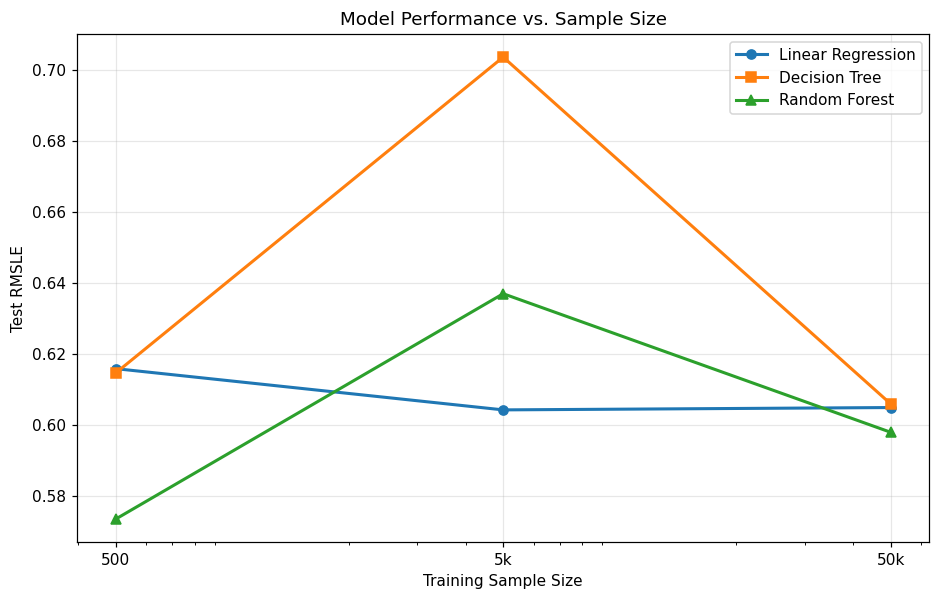

In [41]:
import matplotlib.pyplot as plt

df_results = results.get_table(style=False)

sample_sizes = [500, 5000, 50000]

lr_scores = [
    df_results.loc["Linear (Full Features + Log)", "Test RMSLE"],
    df_results.loc["LR (5k Sample and Full Features)", "Test RMSLE"],
    df_results.loc["LR (50k Sample and Full Features)", "Test RMSLE"]
]

dt_scores = [
    df_results.loc["Tree (depth=3)", "Test RMSLE"], # Using your depth=3 tree as the 500 baseline
    df_results.loc["Decision Tree (5k Sample and Full Features)", "Test RMSLE"],
    df_results.loc["Decision Tree (50k Sample and Full Features)", "Test RMSLE"]
]

rf_scores = [
    df_results.loc["Random Forest (depth=3) with new features", "Test RMSLE"],
    df_results.loc["Random Forest (5k Sample and Full Features)", "Test RMSLE"],
    df_results.loc["Random Forest (50k Sample and Full Features)", "Test RMSLE"]
]

plt.figure(figsize=(10, 6))

plt.plot(sample_sizes, lr_scores, marker='o', linewidth=2, label='Linear Regression')
plt.plot(sample_sizes, dt_scores, marker='s', linewidth=2, label='Decision Tree')
plt.plot(sample_sizes, rf_scores, marker='^', linewidth=2, label='Random Forest')

plt.xscale('log')
plt.xticks(sample_sizes, labels=['500', '5k', '50k'])

plt.xlabel('Training Sample Size')
plt.ylabel('Test RMSLE')
plt.title('Model Performance vs. Sample Size')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### Interpretation after employing different models

* The complex Random Forest outperforms the simple Linear Regression at both the smallest (500 samples) and largest (50k samples) dataset sizes.

* Complex models (Decision Tree and Random Forest) benefit the most from additional data, showing significant error reduction as the dataset scales from 5k to 50k samples.

* In contrast, the simple Linear Regression plateaus very early, showing virtually zero improvement when increasing the data from 5k (Test RMSLE 0.604) to 50k (Test RMSLE 0.605).

#### Finalization

Given into account the results on different models, I'd deploy Random Forest model trained on the 50k dataset with the engineered features, as it provides the best balance of high accuracy and reliability. It achieves a robust 29.8% improvement over the baseline and generalizes well to test data, evidenced by its near-zero train-test gap of 0.001 (no risk of overfitting). As a next step, it should be continued to expand training dataset, as our analysis of the learning curve showed that tree-based models consistently reduce the number of errors as more data is obtained. In addition, it should be explored the possibility of tuning hyperparameters (e.g., increasing tree depth) and incorporating real-time external data, such as traffic conditions or weather conditions, to further improve prediction.